# Bài tập ôn tập — Restaurant Tips Dataset

Nguồn: `tips.csv` (seaborn sample dataset) — hóa đơn nhà hàng và tiền tip.

Bộ dữ liệu có các cột: `total_bill` (tổng hóa đơn, USD), `tip` (tiền tip, USD), `sex`, `smoker` (Yes/No),
`day` (Thu/Fri/Sat/Sun), `time` (Lunch/Dinner), `size` (số người trong bàn).

**Đây là bài tự luyện — chưa có sẵn code mẫu chi tiết như trên lớp.** Em tự viết từng ô theo hướng dẫn `# TODO`.
Nếu bí, xem lại các file mẫu của thầy/cô (`01_Insurance`, `w3_1_Data-Wrangling_tiki`, `EDA`, `w3_2_Matplotlib`...) để nhớ cú pháp.

Cấu trúc bài giống hệt bài kiểm tra: **Phần A (Data Wrangling) → Phần B (Data Profiling & Thống kê mô tả) → Phần C (EDA/Trực quan hoá) → Phần D (Trả lời câu hỏi phân tích)**.

## Setup — Tải dữ liệu

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df_raw = pd.read_csv(url)

# TODO: tạo thêm một số giá trị thiếu (NaN) giả lập để luyện tập xử lý missing values
# Gợi ý: dùng np.random.seed(42), chọn ngẫu nhiên ~5% index của cột "total_bill" và "day", gán = np.nan
# (Nếu không chắc cách làm, có thể bỏ qua bước này và chuyển thẳng sang phần A)

df_raw.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


---
# PHẦN A — DATA WRANGLING
## A.1. Xử lý giá trị thiếu (Missing Values)
Kiểm tra số lượng missing theo từng cột. `day` (phân loại) → điền **mode**. `total_bill` (số) → điền **median**. Nếu có dòng thiếu quá nhiều cột cùng lúc → có thể `dropna`.

In [23]:
# TODO 1: In số lượng missing values của từng cột (df_raw.isnull().sum())
print(df_raw.isnull().sum())
# TODO 2: df = df_raw.copy()
df = df_raw.copy()
# TODO 3: Điền missing cho cột 'day' bằng mode
# Gợi ý: df['day'].fillna(df['day'].mode()[0])
df['day'] = df['day'].fillna(df['day'].mode()[0])
# TODO 4: Điền missing cho cột 'total_bill' bằng median (không nên dùng mean vì dữ liệu tiền thường lệch)
df['total_bill'] = df['total_bill'].fillna(df['total_bill'].median())
# TODO 5: Kiểm tra lại isnull().sum() để chắc chắn không còn missing
print(df_raw.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


## A.2. Sửa định dạng dữ liệu (Correct Data Format)

In [24]:
# TODO 1: In df.dtypes trước khi sửa
print(df.dtypes)
# TODO 2: Ép các cột phân loại 'sex', 'smoker', 'day', 'time' về kiểu category
for col in ["sex", "smoker", "day", "time"]:
    df[col] = df[col].astype('category')
# TODO 3: In lại df.dtypes để kiểm tra
print(df.dtypes)

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


## A.3. Tạo cột mới & Chuẩn hoá dữ liệu (Standardization)
Tạo cột `tip_pct` = phần trăm tiền tip so với hóa đơn (`tip / total_bill`). Đưa cột `smoker` về dạng số: `No → 0`, `Yes → 1` (tên cột `smoker_flag`).

In [25]:
# TODO 1: df['tip_pct'] = df['tip'] / df['total_bill']
df['tip_pot'] = df['tip'] / df['total_bill']
# TODO 2: smoker_map = {'No': 0, 'Yes': 1}; df['smoker_flag'] = df['smoker'].map(smoker_map).astype(int)

# TODO 3: df[['total_bill','tip','tip_pct','smoker','smoker_flag']].head()

## A.4. Chuẩn hoá phạm vi giá trị (Normalization)
Đưa `total_bill` về khoảng 0–1 bằng cách chia cho giá trị lớn nhất.

In [26]:
# TODO: df['total_bill_normalized'] = df['total_bill'] / df['total_bill'].max()
df['total_bill_normalized'] = df['total_bill']/df['total_bill'].max()

In [27]:
df[["total_bill","total_bill_normalized"]].head()

,total_bill,total_bill_normalized
0,16.99,0.334383
1,10.34,0.203503
2,21.01,0.413501
3,23.68,0.466050
4,24.59,0.483960


## A.5. Phân nhóm (Binning)
Chia `total_bill` thành 3 nhóm **Low / Medium / High** bằng `pd.cut()`.

bill_level
Low       140
Medium     88
High       16
Name: count, dtype: int64


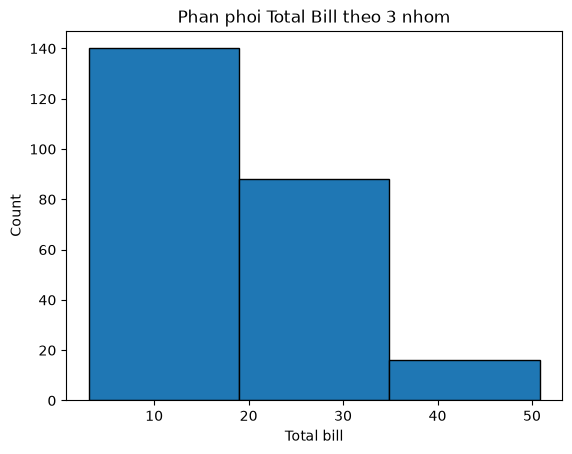

In [28]:
# TODO 1: bins = np.linspace(df['total_bill'].min(), df['total_bill'].max(), 4)

# TODO 2: df['bill_level'] = pd.cut(df['total_bill'], bins=bins, labels=['Low','Medium','High'], include_lowest=True)

# TODO 3: print(df['bill_level'].value_counts())

# TODO 4: plt.hist(df['total_bill'], bins=3); đặt xlabel/ylabel/title rồi plt.show()

bins = np.linspace(df["total_bill"].min(), df["total_bill"].max(), 4)
df["bill_level"] = pd.cut(df["total_bill"], bins=bins, labels=["Low","Medium","High"], include_lowest=True)

print(df["bill_level"].value_counts())

plt.hist(df["total_bill"], bins=3, edgecolor="black")
plt.xlabel("Total bill")
plt.ylabel("Count")
plt.title("Phan phoi Total Bill theo 3 nhom")
plt.show()

## A.6. Biến giả (Dummy Variable)
Biến cột `day` thành các cột 0/1 (`day_Thu`, `day_Fri`,...).

In [29]:
# TODO 1: dummy_day = pd.get_dummies(df['day'], prefix='day', dtype=int)

# TODO 2: df = pd.concat([df, dummy_day], axis=1)

# TODO 3: df.head()

---
# PHẦN B — DATA PROFILING & THỐNG KÊ MÔ TẢ
## B.1. Data size, column names, data types

In [30]:
# TODO: in df.shape, df.columns, df.dtypes
df.shape
df.columns.tolist()
df.dtypes

total_bill                float64
tip                       float64
sex                      category
smoker                   category
day                      category
time                     category
size                        int64
tip_pot                   float64
total_bill_normalized     float64
bill_level               category
dtype: object

## B.2. Kiểm tra dữ liệu không hợp lệ (Invalid values)

In [31]:
# TODO 1: Kiểm tra có total_bill <= 0 hoặc tip < 0 không (dữ liệu vô lý)
# Gợi ý: df[df['total_bill'] <= 0]
print(df[(df["total_bill"] <= 0) | (df["tip"] < 0)])
# TODO 2: Kiểm tra có dòng trùng lặp hoàn toàn không: df.duplicated().sum()

Empty DataFrame
Columns: [total_bill, tip, sex, smoker, day, time, size, tip_pot, total_bill_normalized, bill_level]
Index: []


## B.3. Thống kê mô tả
**Group 1 — Xu hướng trung tâm (Central Tendency):** mean, median, mode của `total_bill` và `tip_pct`.

**Group 2 — Độ phân tán (Dispersion):** std, variance, range, IQR của `total_bill`.

**Group 3 — Vị trí & hình dạng (Location & Shape):** min, max, quartiles, skewness của `tip_pct`.

In [32]:
# TODO Group 1: mean/median/mode
print(df['total_bill'].mean())
print(df['total_bill'].mode()[0])
# TODO Group 2: std, var, (max-min), IQR = Q3 - Q1

# TODO Group 3: describe(), skew()
# Gợi ý: df['tip_pct'].skew()

19.78594262295082
13.42


---
# PHẦN C — EDA & TRỰC QUAN HOÁ (MATPLOTLIB)
## C.1. Phát hiện outlier bằng IQR + Boxplot

<Axes: ylabel='total_bill'>

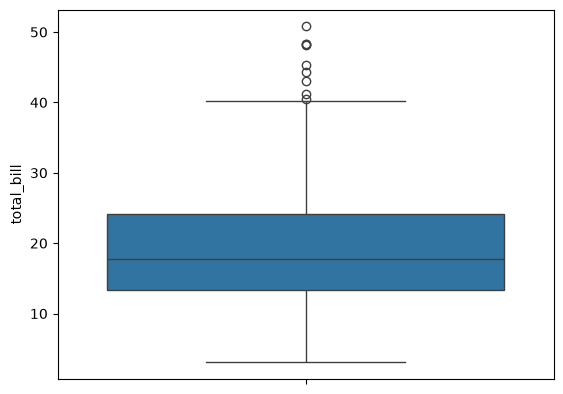

In [34]:
# TODO 1: Tính Q1, Q3, IQR của total_bill
q1 = df['total_bill'].quantile(0.25)
q3 = df['total_bill'].quantile(0.75)
IQR = q3-q1

lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR
# TODO 2: Tính lower_bound = Q1 - 1.5*IQR, upper_bound = Q3 + 1.5*IQR
# TODO 3: In các dòng bị coi là outlier: df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]
df[(df['total_bill'] < lower_bound) | (df['total_bill'] > lower_bound)]
# TODO 4: plt.boxplot(df['total_bill']); title/ylabel; plt.show()

sns.boxplot(df['total_bill'])

## C.2. Phân phối biến số — Histogram

In [38]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pot,total_bill_normalized,bill_level
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,0.334383,Low
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,0.203503,Low
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,0.413501,Medium
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,0.466050,Medium
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,0.483960,Medium


<Axes: xlabel='tip_pot', ylabel='Count'>

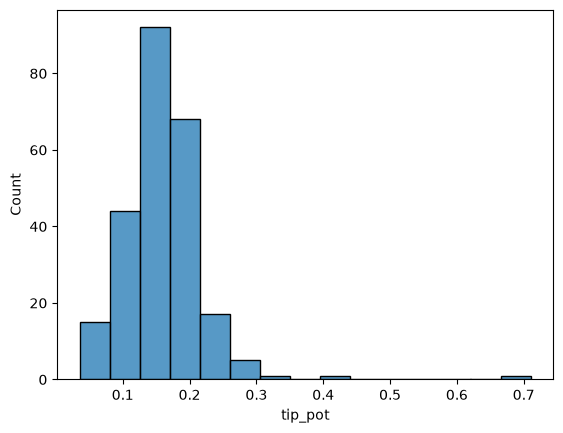

In [39]:
# TODO: vẽ histogram cho 'tip_pct' (plt.hist), đặt bins=15, xlabel/ylabel/title, plt.show()
sns.histplot(df['tip_pot'], bins=15)

## C.3. Quan hệ giữa biến phân loại và biến số — Boxplot theo nhóm

<Axes: xlabel='day', ylabel='total_bill'>

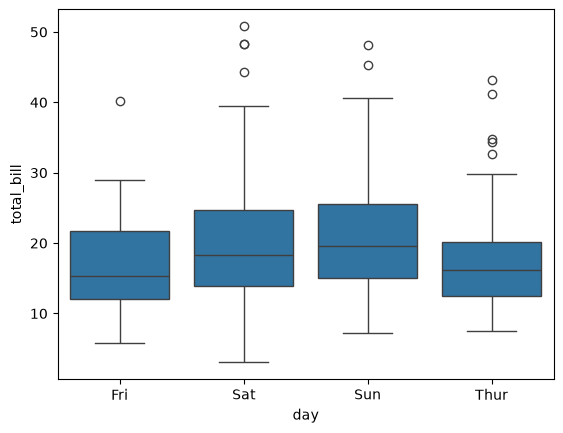

In [44]:
# TODO: Vẽ boxplot của 'total_bill' theo từng 'day'
# Gợi ý cách 1 (matplotlib thuần): nhóm dữ liệu theo day rồi truyền list các mảng vào plt.boxplot()

# Gợi ý cách 2 (nếu có seaborn): sns.boxplot(data=df, x='day', y='total_bill')
sns.boxplot(x=df['day'],y=df['total_bill'])

## C.4. Tương quan giữa các biến số — Scatter & Heatmap

<Axes: >

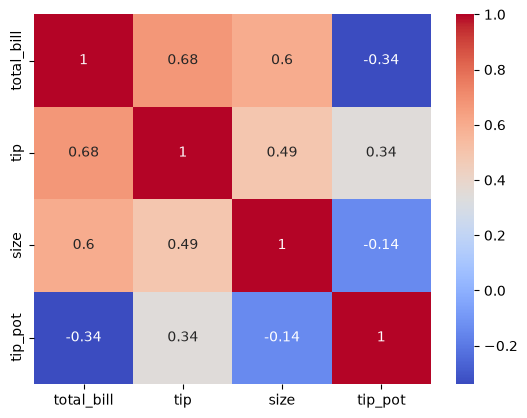

In [50]:
# TODO 1: plt.scatter(df['total_bill'], df['tip']); xlabel/ylabel/title; plt.show()
sns.scatterplot(x=df['total_bill'], y=df['tip'])
# TODO 2: Tính ma trận tương quan giữa total_bill, tip, size, tip_pct
# Gợi ý: df[['total_bill','tip','size','tip_pct']].corr()
cols = ['total_bill','tip','size','tip_pot']
# TODO 3 (nếu có seaborn): sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
sns.heatmap(data=df[cols].corr(), annot=True, cmap='coolwarm')

## C.5. Nhiều biểu đồ trong 1 hình — subplots

In [ ]:
# TODO: Dùng plt.subplots(1, 2, figsize=(12,4)) để vẽ 2 biểu đồ cạnh nhau:
#   - Bên trái: histogram của total_bill
#   - Bên phải: histogram của tip
# Nhớ đặt title cho từng subplot và plt.tight_layout()


---
# PHẦN D — TRẢ LỜI CÂU HỎI PHÂN TÍCH
Với mỗi câu, viết code để tính toán/vẽ biểu đồ, rồi **viết 1-2 câu insight** (nhận xét) bên dưới bằng markdown.

**Câu 1:** Khách hút thuốc (`smoker`) có xu hướng tip % cao hơn hay thấp hơn khách không hút thuốc?

**Câu 2:** Bữa tối (`Dinner`) và bữa trưa (`Lunch`) có khác biệt về `total_bill` trung bình không?

**Câu 3:** Nhóm khách đông người (`size` lớn) có tip % cao hơn nhóm ít người không? (gợi ý: groupby size, tính mean tip_pct)

**Câu 4:** Ngày nào trong tuần (`day`) có tổng doanh thu (`total_bill`) cao nhất?

**Câu 5:** `total_bill` có tương quan với `tip` mạnh như thế nào? Có tương quan với `tip_pct` không? So sánh 2 hệ số này.

**Câu 6 (Tổng hợp):** Viết 3-4 câu insight tổng kết những gì em phát hiện được từ bộ dữ liệu này.

In [ ]:
# TODO Câu 1


In [ ]:
# TODO Câu 2


In [ ]:
# TODO Câu 3


In [ ]:
# TODO Câu 4


In [ ]:
# TODO Câu 5


**Câu 6 — Insight tổng hợp:**

_(Em viết nhận xét ở đây)_